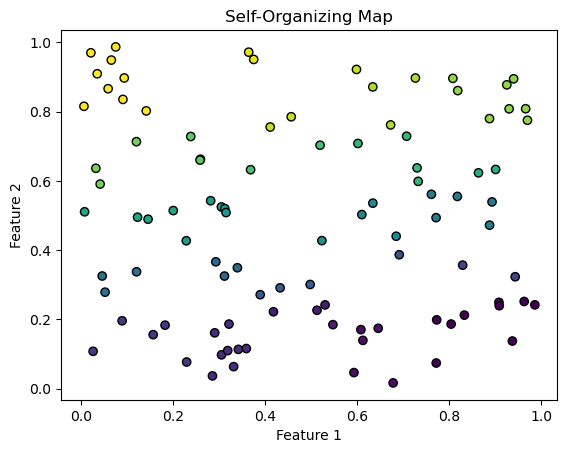

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class SOM:
    def __init__(self, input_size, map_size):
        self.input_size = input_size
        self.map_size = map_size
        self.weights = np.random.rand(map_size[0], map_size[1], input_size)

    def find_best_matching_unit(self, input_vector):
        # Compute distances to all neurons
        distances = np.linalg.norm(self.weights - input_vector, axis=2)
        # Find the indices of the neuron with the smallest distance (Best matching unit)
        bmu_indices = np.unravel_index(np.argmin(distances), distances.shape)
        return bmu_indices

    def update_weights(self, input_vector, bmu_indices, learning_rate, sigma):
        # Compute the neighborhood function (Gaussian)
        x, y = np.meshgrid(np.arange(self.map_size[0]), np.arange(self.map_size[1]), indexing='ij')
        distances = np.sqrt((x - bmu_indices[0])**2 + (y - bmu_indices[1])**2)
        neighborhood_function = np.exp(-distances**2 / (2 * sigma**2))

        # Update weights for all neurons
        self.weights += learning_rate * neighborhood_function[:, :, np.newaxis] * (input_vector - self.weights)

    def train(self, data, num_epochs, learning_rate_initial, sigma_initial):
        for epoch in range(num_epochs):
            for input_vector in data:
                bmu_indices = self.find_best_matching_unit(input_vector)
                learning_rate = learning_rate_initial * np.exp(-epoch / num_epochs)
                sigma = sigma_initial * np.exp(-epoch / num_epochs)
                self.update_weights(input_vector, bmu_indices, learning_rate, sigma)

    def predict(self, data):
        predictions = np.zeros(len(data), dtype=int)
        for i, input_vector in enumerate(data):
            bmu_indices = self.find_best_matching_unit(input_vector)
            predictions[i] = bmu_indices[0] * self.map_size[1] + bmu_indices[1]
        return predictions

# Generate a synthetic dataset
np.random.seed(42)
data = np.random.rand(100, 2)

# Create and train a Self-Organizing Map
input_size = 2
map_size = (5, 5)
som = SOM(input_size, map_size)
som.train(data, num_epochs=10, learning_rate_initial=0.1, sigma_initial=2.0)

# Make predictions
predictions = som.predict(data)

# Visualize the SOM grid
plt.scatter(data[:, 0], data[:, 1], c=predictions, cmap='viridis', marker='o', edgecolor='k')
plt.title('Self-Organizing Map')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()
